# CURE-TSD Dataset Preparation
  - YOLOv8 Single-Class Dataset (traffic_sign)
  - CNN Training Crops from No-Challenge GT boxes

###  Imports & Path Configuration

In [ ]:
from pathlib import Path
import pandas as pd
import random
from PIL import Image

###  USER CONFIG

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/subset.zip

Streaming output truncated to the last 5000 lines.
  inflating: subset/labels/test/01_06_00_00_073.txt  
  inflating: subset/labels/test/01_39_07_02_283.txt  
  inflating: subset/labels/test/01_21_00_00_238.txt  
  inflating: subset/labels/test/01_31_09_02_151.txt  
  inflating: subset/labels/test/01_06_02_01_105.txt  
  inflating: subset/labels/test/01_21_00_00_103.txt  
  inflating: subset/labels/test/01_08_06_01_011.txt  
  inflating: subset/labels/test/01_21_06_01_207.txt  
  inflating: subset/labels/test/01_08_06_01_268.txt  
  inflating: subset/labels/test/01_06_00_00_054.txt  
  inflating: subset/labels/test/01_07_02_02_080.txt  
  inflating: subset/labels/test/01_04_07_02_165.txt  
  inflating: subset/labels/test/01_08_06_01_215.txt  
  inflating: subset/labels/test/01_24_02_01_194.txt  
  inflating: subset/labels/test/01_08_07_02_189.txt  
  inflating: subset/labels/test/01_39_00_00_172.txt  
  inflating: subset/labels/test/01_39_07_02_113.txt  
  inflating: subset/labels/test

## Dataset Paths and Export Configuration

This section defines where the dataset is read from and how outputs are organized for two parallel workflows. One workflow prepares a **single-class YOLO detection dataset**, while the other produces **CNN-ready crops** extracted from ground-truth bounding boxes. Separating these outputs avoids file collisions and keeps detection and classification experiments clean and reproducible.

The dataset is assumed to follow a consistent structure under a root directory, with a CSV file providing frame-level metadata and a labels folder storing annotations. Centralizing paths and split definitions makes the export process deterministic and easier to maintain.

A fixed train/validation split ratio and random seed are used to ensure reproducibility, with splitting performed at the sequence level to prevent leakage between highly correlated frames. Crop-related parameters are chosen to preserve small and distant traffic signs while filtering unusable annotations.

Finally, challenge types and severity levels from the CSV are mapped explicitly to test subsets. This allows each frame to be routed to the correct evaluation split in a transparent and repeatable way, including a dedicated clean test set for uncorrupted data.

In [ ]:
SRC_ROOT = Path("subset")  # your original dataset folder
CSV_PATH = SRC_ROOT / "classification_labels.csv"
SRC_LABELS = SRC_ROOT / "labels"

# Output: YOLO single-class dataset
YOLO_OUT = Path("curetsd_yolo_single")

# Output: CNN crops dataset (no_challenge only, GT-based)
CNN_OUT = Path("cnn_crops_no_challenge")  # NEW folder

# Train/Val split settings (split on sequences to avoid leakage)
VAL_RATIO = 0.10
SEED = 42
random.seed(SEED)

# CNN crop settings
CNN_INPUT_SIZE = 64         # recommended >32 for small/far signs
CROP_PADDING_PX = 6         # add a small padding around bbox (in pixels)
MIN_BOX_SIZE_PX = 6         # filter extremely tiny boxes

# YOLO subset list
SPLITS = [
    "train", "val",
    "test_clean",
    "test_lens_blur_l1", "test_lens_blur_l2",
    "test_exposure_l1", "test_exposure_l2",
    "test_gaussian_blur_l1", "test_gaussian_blur_l2",
    "test_rain_l1", "test_rain_l2",
]

# CSV column names
FRAME_COL = "frame"
CHALL_COL = "challenge"
LEVEL_COL = "level"

# Challenge+level -> test subset mapping
TEST_SUBSET_MAP = {
    ("no_challenge", 0): "test_clean",
    ("lens_blur", 1): "test_lens_blur_l1",
    ("lens_blur", 2): "test_lens_blur_l2",
    ("exposure", 1): "test_exposure_l1",
    ("exposure", 2): "test_exposure_l2",
    ("gaussian_blur", 1): "test_gaussian_blur_l1",
    ("gaussian_blur", 2): "test_gaussian_blur_l2",
    ("rain", 1): "test_rain_l1",
    ("rain", 2): "test_rain_l2",
}

### IO Helpers

This block contains small helper functions used throughout the pipeline for basic file handling and numeric safety. Since each function is short and self-explanatory, the focus is on their **intent and usage context** rather than internal mechanics.

- The directory helper ensures output paths exist before writing files, which avoids repetitive checks in the main logic. 
- Path resolution adds a simple fallback mechanism for image locations that may be stored with different base directories in metadata files. 
- File copying is guarded to prevent unnecessary overwrites when rerunning the script
- clamp function provides a concise way to keep values within valid bounds, typically when working with image coordinates.


In [ ]:
# create directories
def mkdir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

# create a fallpback path resolver
def resolve_image_path(frame_path_str: str) -> Path:
    p = Path(frame_path_str)
    if p.exists():
        return p

    fallback = SRC_ROOT.parent / frame_path_str
    if fallback.exists():
        return fallback

    return p

# copy file if it doesn't exist
def copy_file(src: Path, dst: Path):
    if dst.exists():
        return
    dst.write_bytes(src.read_bytes())

# clamp value between lo and hi
def clamp(v, lo, hi):
    return max(lo, min(v, hi))

###  Label Parsing (Original Corner Format)

This block handles the conversion from **corner-based ground-truth annotations** to formats that are directly usable by detection models. The explanations are kept concise, as each function performs a focused and standard transformation.

The `read_gt_corner_labels` function reads a label file where each object is described by a class identifier followed by eight numbers representing the `(x, y)` coordinates of its four corners. Empty or malformed files are safely ignored. For valid lines, the corners are grouped into `(x, y)` pairs and returned in a simple dictionary structure, which makes downstream geometric processing explicit and easy to follow.

The `corners_to_xyxy` function converts these corner coordinates into an axis-aligned bounding box in `(xmin, ymin, xmax, ymax)` format. It computes the tight box enclosing all corners, optionally expands it by a small padding, and then clamps the result to valid image boundaries. This step bridges the gap between polygon-style annotations and rectangular crops or detector-friendly boxes.

The `xyxy_to_yolo_line_single_class` function converts the pixel-space bounding box into **YOLO normalized format**. Width, height, and center coordinates are derived from the corner-based box and normalized by the image dimensions. A fixed class ID of `0` is used, reflecting the single-class detection setup, and the output is returned as a formatted string ready to be written directly into a YOLO label file.

In [ ]:
def read_gt_corner_labels(src_label_path: Path):
    if not src_label_path.exists():
        return []

    text = src_label_path.read_text().strip()
    if not text:
        return []

    objs = []
    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) < 9:
            continue

        sign_type = int(parts[0])
        coords = list(map(float, parts[1:9]))  # 8 numbers
        corners = [(coords[i], coords[i + 1]) for i in range(0, 8, 2)]
        objs.append({"sign_type": sign_type, "corners": corners})

    return objs

def corners_to_xyxy(corners, W, H, pad_px=0):
    xs = [p[0] for p in corners]
    ys = [p[1] for p in corners]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    # optional padding around the tight box
    xmin -= pad_px
    ymin -= pad_px
    xmax += pad_px
    ymax += pad_px

    # clamp + int conversion so boxes stay valid inside image bounds
    xmin = int(clamp(round(xmin), 0, W - 1))
    ymin = int(clamp(round(ymin), 0, H - 1))
    xmax = int(clamp(round(xmax), 0, W - 1))
    ymax = int(clamp(round(ymax), 0, H - 1))

    return xmin, ymin, xmax, ymax

def xyxy_to_yolo_line_single_class(xmin, ymin, xmax, ymax, W, H):
    bw = max(1, xmax - xmin)   # avoid zero/negative width from bad/degenerate boxes
    bh = max(1, ymax - ymin)
    xc = xmin + bw / 2.0
    yc = ymin + bh / 2.0

    # YOLO expects normalized (0..1) center x/y and width/height
    xc /= W
    yc /= H
    bw /= W
    bh /= H

    return f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"

### Sequence-based Train/Val Split (No-Challenge Only)

This helper extracts a sequence-level identifier from a frame name by splitting the filename stem on underscores. If the name follows the expected convention, the first two components are combined to form a stable sequence ID. This is typically used to group related frames so that train/validation splits can be performed at the sequence level rather than per frame, reducing temporal leakage. If the naming pattern does not match the expectation, the original stem is returned as a safe fallback.


In [ ]:
def get_seq_id_from_stem(stem: str):
    parts = stem.split("_")
    if len(parts) >= 2:
        return f"{parts[0]}_{parts[1]}"
    return stem

### Build Output Folder Structure

This function creates the required directory structure for all dataset outputs before any files are written. For the YOLO pipeline, it initializes separate `images` and `labels` folders for each defined split, ensuring a consistent layout across training, validation, and test subsets. For the CNN pipeline, it prepares image-only folders for the train and validation sets, reflecting the crop-based classification setup where labels are typically inferred from folder structure or metadata. Centralizing folder creation avoids repeated checks later in the pipeline and makes reruns safe and idempotent.


In [ ]:
def init_output_folders():
    # YOLO folders
    for s in SPLITS:
        mkdir(YOLO_OUT / "images" / s)
        mkdir(YOLO_OUT / "labels" / s)

    # CNN folders
    mkdir(CNN_OUT / "train" / "images")
    mkdir(CNN_OUT / "val" / "images")

### YOLO Builder (Single-Class)

This function builds a single YOLO dataset split by iterating over a subset of frames defined in a dataframe. For each frame, it resolves the image path, loads the image to obtain its dimensions, and reads the corresponding ground-truth annotations. Corner-based annotations are converted into axis-aligned bounding boxes and then formatted into single-class YOLO label lines.

Images are copied into the appropriate split folder, and a label file is written for each image. Empty label files are intentionally allowed, as YOLO treats them as valid negatives. Extremely small boxes are filtered out to reduce noise. At the end of the process, a short summary is printed to report how many frames were processed and how many images were missing.

In [ ]:
def build_yolo_split(rows_df: pd.DataFrame, src_label_split: str, dst_split: str):
    done, missing = 0, 0

    for frame_path_str in rows_df[FRAME_COL].tolist():
        src_img = resolve_image_path(frame_path_str)
        if not src_img.exists():
            missing += 1
            continue

        stem = src_img.stem
        src_lbl = SRC_LABELS / src_label_split / f"{stem}.txt"

        with Image.open(src_img) as im:
            im = im.convert("RGB")
            W, H = im.size

        gt_objs = read_gt_corner_labels(src_lbl)

        # Prepare YOLO label lines
        yolo_lines = []
        for obj in gt_objs:
            xmin, ymin, xmax, ymax = corners_to_xyxy(obj["corners"], W, H, pad_px=0)
            if (xmax - xmin) < MIN_BOX_SIZE_PX or (ymax - ymin) < MIN_BOX_SIZE_PX:
                continue
            yolo_lines.append(xyxy_to_yolo_line_single_class(xmin, ymin, xmax, ymax, W, H))

        # Copy image
        dst_img = YOLO_OUT / "images" / dst_split / src_img.name
        copy_file(src_img, dst_img)

        # Write label (empty is valid YOLO case)
        dst_lbl = YOLO_OUT / "labels" / dst_split / f"{stem}.txt"
        dst_lbl.write_text("\n".join(yolo_lines) + ("\n" if yolo_lines else ""))

        done += 1

    print(f"[YOLO:{dst_split}] processed={done}, missing_images={missing}")

### CNN Crops Builder (No-Challenge, GT-based)

This function builds the **CNN crop dataset** for either the training or validation split using ground-truth annotations. It iterates over the frames listed in the provided dataframe, resolves each image path, and loads the image to obtain its spatial dimensions. Frames without valid images or without annotations are skipped early to keep the dataset clean.

For each annotated object, corner-based ground-truth labels are converted into padded bounding boxes, and very small boxes are filtered out. Each valid region is cropped from the original image, resized to a fixed input resolution, and saved as an individual image. Class labels are remapped to a zero-based index to match standard CNN classification conventions.

Alongside the image crops, the function collects structured metadata for every crop, including the source image, bounding box coordinates, and preprocessing parameters. This metadata is written to a CSV file for the corresponding split, enabling reproducible training, debugging, and downstream analysis. A short summary is printed at the end to report processing statistics and output locations.


In [ ]:
def build_cnn_crops(rows_df: pd.DataFrame, src_label_split: str, dst_split: str):
    assert dst_split in ["train", "val"]

    out_rows = []
    done, missing = 0, 0

    for frame_path_str in rows_df[FRAME_COL].tolist():
        src_img = resolve_image_path(frame_path_str)
        if not src_img.exists():
            missing += 1         # image path listed but file not found
            continue

        stem = src_img.stem
        src_lbl = SRC_LABELS / src_label_split / f"{stem}.txt"

        im = Image.open(src_img).convert("RGB")
        W, H = im.size

        gt_objs = read_gt_corner_labels(src_lbl)
        if len(gt_objs) == 0:
            continue        # skip frames with no valid GT objects

        obj_idx = 0
        for obj in gt_objs:
            # GT class for CNN: signType 1..14 -> 0..13
            gt_class_id = int(obj["sign_type"]) - 1

            xmin, ymin, xmax, ymax = corners_to_xyxy(obj["corners"], W, H, pad_px=CROP_PADDING_PX)
            if (xmax - xmin) < MIN_BOX_SIZE_PX or (ymax - ymin) < MIN_BOX_SIZE_PX:
                continue

            crop = im.crop((xmin, ymin, xmax, ymax))
            crop = crop.resize((CNN_INPUT_SIZE, CNN_INPUT_SIZE))

            crop_name = f"{stem}_gt{obj_idx:02d}_cls{gt_class_id:02d}.jpg"
            crop_path = CNN_OUT / dst_split / "images" / crop_name
            crop.save(crop_path)

            # store metadata to reconstruct crop origin and training labels
            out_rows.append({
                "split": dst_split,
                "crop_path": str(crop_path),
                "gt_class_id": gt_class_id,
                "source_image": str(src_img),
                "source_name": src_img.name,
                "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax,
                "cnn_input_size": CNN_INPUT_SIZE,
                "padding_px": CROP_PADDING_PX
            })

            obj_idx += 1

        done += 1

    df_out = pd.DataFrame(out_rows)
    out_csv = CNN_OUT / f"{dst_split}_labels.csv"
    df_out.to_csv(out_csv, index=False)

    print(f"[CNN:{dst_split}] images_processed={done}, missing_images={missing}, crops={len(df_out)}")
    print(f"[CNN:{dst_split}] saved labels CSV: {out_csv}")

### Main Pipeline

This `main()` function orchestrates the full dataset export workflow end-to-end. It first initializes output folders, loads the CSV metadata, and then constructs a leakage-safe train/validation split using only **clean (no_challenge, level 0)** training frames. The split is performed at the **sequence level** using a derived `seq_id`, so near-duplicate frames from the same driving sequence do not end up in both train and validation.

After the split is created, the script exports two parallel datasets. For detection, it builds a **single-class YOLO** train/val dataset and also generates YOLO-formatted test subsets for each corruption type and severity using the `(challenge, level) → subset` mapping. A minimal YOLO YAML file is then written to make training plug-and-play.

Finally, the script creates a **CNN crop dataset** from the same clean train/val frames using ground-truth boxes, saving both cropped images and a CSV that records crop metadata and class IDs. The final print statements summarize where the two output datasets were written.

In [ ]:
def main():
    init_output_folders()

    df = pd.read_csv(CSV_PATH)
    print("CSV columns:", list(df.columns))
    print("Total rows:", len(df))

    # ---- A) Create Train/Val split from TRAIN + no_challenge only
    df_train_clean = df[
        (df[FRAME_COL].str.contains("/train/")) &
        (df[CHALL_COL] == "no_challenge") &
        (df[LEVEL_COL] == 0)
    ].copy()

    df_train_clean["stem"] = df_train_clean[FRAME_COL].apply(lambda p: Path(p).stem)
    df_train_clean["seq_id"] = df_train_clean["stem"].apply(get_seq_id_from_stem)

    seq_ids = sorted(df_train_clean["seq_id"].unique().tolist())
    random.shuffle(seq_ids)

    val_seq_count = max(1, int(len(seq_ids) * VAL_RATIO))
    val_seq_ids = set(seq_ids[:val_seq_count])
    train_seq_ids = set(seq_ids[val_seq_count:])

    df_train = df_train_clean[df_train_clean["seq_id"].isin(train_seq_ids)].copy()
    df_val   = df_train_clean[df_train_clean["seq_id"].isin(val_seq_ids)].copy()

    print("\n=== Split Summary (No-Challenge) ===")
    print("No-challenge samples:", len(df_train_clean))
    print("Train images:", len(df_train))
    print("Val images:", len(df_val))
    print("Unique sequences:", len(seq_ids), "| Val sequences:", len(val_seq_ids))

    # ---- B) Build YOLO train/val (single-class)
    print("\n=== Building YOLO Single-Class (Train/Val) ===")
    build_yolo_split(df_train, src_label_split="train", dst_split="train")
    build_yolo_split(df_val,   src_label_split="train", dst_split="val")

    # ---- C) Build YOLO test subsets (single-class)
    print("\n=== Building YOLO Single-Class (Test Subsets) ===")
    df_test_all = df[df[FRAME_COL].str.contains("/test/")].copy()

    subset_counts = {}
    for (ch, lv), subset_name in TEST_SUBSET_MAP.items():
        sub_df = df_test_all[(df_test_all[CHALL_COL] == ch) & (df_test_all[LEVEL_COL] == lv)].copy()
        subset_counts[subset_name] = len(sub_df)
        build_yolo_split(sub_df, src_label_split="test", dst_split=subset_name)

    print("\nTest subset counts:", subset_counts)

    # ---- D) Write YOLO YAML (single class)
    print("\n=== Writing YOLO YAML (Single-Class) ===")
    yaml_text = f"""path: {YOLO_OUT.resolve()}
train: images/train
val: images/val
names: [traffic_sign]
        """
    (YOLO_OUT / "curetsd_single.yaml").write_text(yaml_text)
    print(yaml_text)
    print("Saved:", YOLO_OUT / "curetsd_single.yaml")

    # ---- E) Build CNN crops from GT on no-challenge (train/val)
    print("\n=== Building CNN Crops (No-Challenge, GT-based) ===")
    build_cnn_crops(df_train, src_label_split="train", dst_split="train")
    build_cnn_crops(df_val,   src_label_split="train", dst_split="val")

    print("\nDONE.")
    print("YOLO single-class dataset:", YOLO_OUT.resolve())
    print("CNN crops dataset:", CNN_OUT.resolve())

In [ ]:
main()

CSV columns: ['frame', 'challenge', 'level']
Total rows: 54171

=== Split Summary (No-Challenge) ===
No-challenge samples: 3917
Train images: 3575
Val images: 342
Unique sequences: 27 | Val sequences: 2

=== Building YOLO Single-Class (Train/Val) ===
[YOLO:train] processed=3575, missing_images=0
[YOLO:val] processed=342, missing_images=0

=== Building YOLO Single-Class (Test Subsets) ===
[YOLO:test_clean] processed=2102, missing_images=0
[YOLO:test_lens_blur_l1] processed=2102, missing_images=0
[YOLO:test_lens_blur_l2] processed=2102, missing_images=0
[YOLO:test_exposure_l1] processed=2102, missing_images=0
[YOLO:test_exposure_l2] processed=2102, missing_images=0
[YOLO:test_gaussian_blur_l1] processed=2102, missing_images=0
[YOLO:test_gaussian_blur_l2] processed=2102, missing_images=0
[YOLO:test_rain_l1] processed=2102, missing_images=0
[YOLO:test_rain_l2] processed=2102, missing_images=0

Test subset counts: {'test_clean': 2102, 'test_lens_blur_l1': 2102, 'test_lens_blur_l2': 2102, 't

# YOLO-V8 FINE TUNING

In [ ]:
!pip install -U ultralytics


In [ ]:
from pathlib import Path
import re
from ultralytics import YOLO


### Set Paths + Fix YAML path: for Colab

This block sets dataset paths and ensures the YAML `path:` field points to the dataset root visible in the current runtime. This matters in Colab/Drive setups where the dataset folder can move, and a stale YAML path silently breaks training.

If your YAML already contains the correct absolute/relative path, you can skip the `re.sub(...)` rewrite and just print the YAML to confirm.

In [ ]:

# === EDIT IF NEEDED ===
YOLO_ROOT = Path("curetsd_yolo_single")   # dataset root
DATA_YAML = YOLO_ROOT / "curetsd_single.yaml"                   # single-class yaml
RUNS_DIR  = Path("runs_curetsd_single")   # training outputs saved to Drive
# ======================

assert YOLO_ROOT.exists(), f"Dataset folder not found: {YOLO_ROOT}"
assert DATA_YAML.exists(), f"YAML file not found: {DATA_YAML}"

# Ensure YAML "path:" points to the Drive dataset root
yaml_text = DATA_YAML.read_text()
yaml_text = re.sub(r"^path:.*$", f"path: {YOLO_ROOT}", yaml_text, flags=re.MULTILINE)
DATA_YAML.write_text(yaml_text)

print("Updated YAML:\n")
print(DATA_YAML.read_text())


Updated YAML:

path: curetsd_yolo_single
train: images/train
val: images/val
names: [traffic_sign]


### Fine-tune YOLOv8 (Single-Class)

This launches training from `yolov8s.pt` using your single-class YAML. The key idea is that your dataset contains only one class (`traffic_sign`), so YOLO learns detection robustness without having to separate sign categories at the detection stage.

Settings like `imgsz=1024` target small/far signs by keeping more spatial detail. `close_mosaic=10` is commonly used to stabilize final epochs by turning off mosaic augmentation near the end, often improving box tightness.

In [ ]:
model = YOLO("yolov8s.pt")

results = model.train(
    data=str(DATA_YAML),


    epochs=100,
    imgsz=1024,
    batch=16,
    device=0,          # CUDA GPU
    workers=4,

    degrees=15,

    # Training stability / speed
    patience=30,       # early stopping on val
    cache=True,        # cache images in RAM (if RAM is enough)
    close_mosaic=10,   # disable mosaic in last 10 epochs (often improves final box quality)

    # Output management (save directly to Drive)
    project=str(RUNS_DIR),
    name="yolov8n_singleclass_img1024"
)


Ultralytics 8.3.243 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curetsd_yolo_single/curetsd_single.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_singleclass_img10242, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

### Locate & Copy best.pt / last.pt

This cell helps you verify where Ultralytics saved checkpoints and confirms `best.pt` and `last.pt` exist. It is mainly a sanity check; training already saves weights automatically.

In [ ]:
run_dir = Path("runs_curetsd_single/yolov8n_singleclass_img10242")
best_pt = run_dir / "weights" / "best.pt"
last_pt = run_dir / "weights" / "last.pt"

print("Best:", best_pt, "exists:", best_pt.exists())
print("Last:", last_pt, "exists:", last_pt.exists())


Best: runs_curetsd_single/yolov8n_singleclass_img10242/weights/best.pt exists: True
Last: runs_curetsd_single/yolov8n_singleclass_img10242/weights/last.pt exists: True


# CNN - TRAINING

### Setup (Drive + imports)

In [ ]:
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import torchvision.transforms as T

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.9.0+cu126
CUDA available: True


### Paths & Reproducibility

This sets seeds and loads the crop-label CSVs generated earlier. The two CSVs are the “truth source” for crop paths and class labels, so these asserts protect you from training on an empty or missing dataset.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- EDIT IF NEEDED ---
CNN_ROOT = Path("cnn_crops_no_challenge")
TRAIN_CSV = CNN_ROOT / "train_labels.csv"
VAL_CSV   = CNN_ROOT / "val_labels.csv"
OUT_DIR   = Path("runs_cnn_curetsd")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ----------------------

assert TRAIN_CSV.exists(), f"Missing: {TRAIN_CSV}"
assert VAL_CSV.exists(), f"Missing: {VAL_CSV}"

df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)

print("Train rows:", len(df_train), "| Val rows:", len(df_val))
print(df_train.head(3))


Train rows: 6437 | Val rows: 855
   split                                          crop_path  gt_class_id  \
0  train  cnn_crops_no_challenge/train/images/01_34_00_0...           13   
1  train  cnn_crops_no_challenge/train/images/01_11_00_0...            8   
2  train  cnn_crops_no_challenge/train/images/01_33_00_0...            4   

                              source_image          source_name  xmin  ymin  \
0  subset/frames/train/01_34_00_00_068.jpg  01_34_00_00_068.jpg   941   211   
1  subset/frames/train/01_11_00_00_220.jpg  01_11_00_00_220.jpg   948   162   
2  subset/frames/train/01_33_00_00_021.jpg  01_33_00_00_021.jpg   891   221   

   xmax  ymax  cnn_input_size  padding_px  
0   968   241              64           6  
1   996   207              64           6  
2   923   252              64           6  


### Dataset & Transforms

This defines a dataset wrapper that loads crop images from disk and applies augmentation only in training. The transforms are mild and consistent with traffic signs `(small rotations, slight color jitter, occasional blur)`, which helps generalization without radically altering shape.

In [ ]:
NUM_CLASSES = 14
# infer input size from CSV (keeps train/val consistent); fallback for older CSVs
IMG_SIZE = int(df_train["cnn_input_size"].iloc[0]) if "cnn_input_size" in df_train.columns else 64
print("CNN input size:", IMG_SIZE)

train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), # safety: ensure all crops match model input
    T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10)], p=0.6),
    T.RandomRotation(degrees=15),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.20),
    T.ToTensor(),
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), # no aug in val; just deterministic sizing 
    T.ToTensor(),
])

class CropsCSVDataset(Dataset):

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True) # stable integer indexing for DataLoader
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row["crop_path"])
        y = int(row["gt_class_id"]) # integer class id for CrossEntropyLoss

        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        return img, y

train_ds = CropsCSVDataset(df_train, transform=train_tfms)
val_ds   = CropsCSVDataset(df_val, transform=val_tfms)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))


CNN input size: 64
Train batches: 101 | Val batches: 14


### Model

`MiniCNN` is a compact baseline classifier tailored for small, tightly cropped inputs (e.g., 64×64 traffic sign patches produced by a detector). The architecture intentionally avoids heavy backbones to ensure fast inference and stable training, making it suitable for real-time or embedded scenarios.

- `Hierarchical feature blocks`: Each block uses stacked 3×3 convolutions to capture local patterns (edges → shapes → symbol structure), followed by max pooling to progressively reduce spatial resolution.

- `Batch Normalization + ReLU`: Improves convergence speed and reduces sensitivity to batch statistics, which is important when training on cropped datasets.

- `Global Average Pooling (GAP)`: Replaces large fully connected layers, drastically reducing parameters and overfitting while enforcing spatial robustness.

- `Dropout regularization`: Helps generalization when the number of training crops is limited or class imbalance exists.

- `Lightweight design`: With only three downsampling stages and a small channel budget, MiniCNN serves as a strong, interpretable baseline for traffic sign classification and as a reference point for more complex CNN or detector-classifier pipelines.

In [ ]:
class MiniCNN(nn.Module):
    """
    MiniCNN is a compact baseline CNN classifier designed for small image crops
    (e.g., 64×64 traffic sign patches). It prioritizes speed and training stability
    while maintaining enough representational capacity to separate 14 classes.
    """
    def __init__(self, num_classes=14):
        super().__init__()

        def block(in_ch, out_ch):
            # Two 3×3 convolutions for local feature extraction,
            # followed by spatial downsampling via max pooling
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),  # stabilizes training across batches
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)          # halves spatial resolution
            )

        self.features = nn.Sequential(
            block(3, 32),    # 64->32
            block(32, 64),   # 32->16
            nn.Sequential(   # 16->8
                nn.Conv2d(64, 128, 3, padding=1, bias=False),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )
        )

        # Global average pooling removes spatial dependence and reduces parameters
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        # Dropout improves generalization on small cropped datasets
        self.dropout = nn.Dropout(p=0.30)
        # Final linear classifier mapping features to class logits
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniCNN(num_classes=NUM_CLASSES).to(device)

print(model)


MiniCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplac

### Train Loop (save BEST by val accuracy)

This trains the CNN and saves two checkpoints: `cnn_last.pt` every epoch and `cnn_best.pt` whenever validation accuracy improves. A `ReduceLROnPlateau` scheduler reduces LR if validation stalls, which typically helps stabilize training without manual tuning.

In [ ]:
from time import time

EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss() # standard multi-class classification loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

def accuracy_from_logits(logits, y):
    # compute batch accuracy from raw class logits
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

best_val_acc = -1.0
best_path = OUT_DIR / "cnn_best.pt"
last_path = OUT_DIR / "cnn_last.pt"

# store epoch-wise metrics for later plotting/analysis
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time()

    # ---- Train ----
    model.train()
    train_loss_sum = 0.0
    train_acc_sum = 0.0
    n_train = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        train_loss_sum += loss.item() * bs
        train_acc_sum  += accuracy_from_logits(logits, y) * bs
        n_train += bs

    train_loss = train_loss_sum / n_train
    train_acc  = train_acc_sum / n_train

    # ---- Validate ----
    model.eval()
    val_loss_sum = 0.0
    val_acc_sum = 0.0
    n_val = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            bs = x.size(0)
            val_loss_sum += loss.item() * bs
            val_acc_sum  += accuracy_from_logits(logits, y) * bs
            n_val += bs

    val_loss = val_loss_sum / n_val
    val_acc  = val_acc_sum / n_val

    # Scheduler step
    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Save LAST every epoch
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "val_acc": val_acc,
        "img_size": IMG_SIZE,
        "num_classes": NUM_CLASSES
    }, last_path)

    # Save BEST
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": val_acc,
            "img_size": IMG_SIZE,
            "num_classes": NUM_CLASSES
        }, best_path)

    dt = time() - t0
    lr_now = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"lr={lr_now:.2e} | {dt:.1f}s")

print("\nSaved BEST:", best_path)
print("Saved LAST:", last_path)
print("Best val acc:", best_val_acc)


Epoch 001/40 | train_loss=0.9673 train_acc=0.7283 | val_loss=0.5203 val_acc=0.8480 | lr=1.00e-03 | 5.9s
Epoch 002/40 | train_loss=0.4701 train_acc=0.8723 | val_loss=0.5228 val_acc=0.8292 | lr=1.00e-03 | 5.6s
Epoch 003/40 | train_loss=0.2784 train_acc=0.9360 | val_loss=0.3116 val_acc=0.8655 | lr=1.00e-03 | 5.6s
Epoch 004/40 | train_loss=0.2136 train_acc=0.9470 | val_loss=0.7354 val_acc=0.7942 | lr=1.00e-03 | 5.6s
Epoch 005/40 | train_loss=0.1371 train_acc=0.9708 | val_loss=0.6289 val_acc=0.8550 | lr=1.00e-03 | 5.6s
Epoch 006/40 | train_loss=0.1035 train_acc=0.9789 | val_loss=0.3990 val_acc=0.8608 | lr=1.00e-03 | 5.5s
Epoch 007/40 | train_loss=0.0847 train_acc=0.9818 | val_loss=0.6515 val_acc=0.8678 | lr=1.00e-03 | 5.5s
Epoch 008/40 | train_loss=0.0831 train_acc=0.9814 | val_loss=0.4574 val_acc=0.8608 | lr=1.00e-03 | 5.6s
Epoch 009/40 | train_loss=0.0527 train_acc=0.9896 | val_loss=0.3409 val_acc=0.8854 | lr=1.00e-03 | 5.7s
Epoch 010/40 | train_loss=0.0441 train_acc=0.9905 | val_loss=0.5

### Plot training curves

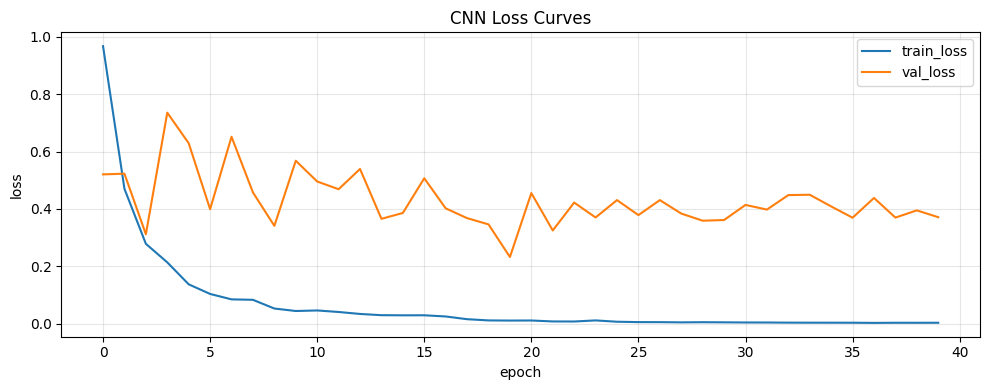

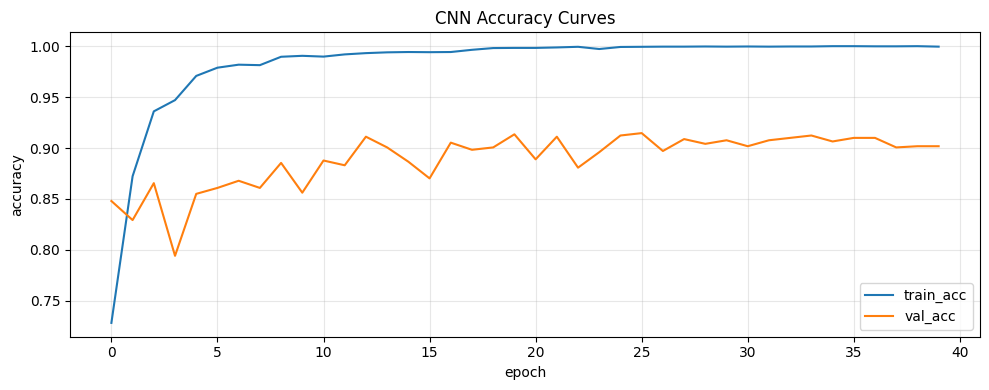

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("CNN Loss Curves")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("CNN Accuracy Curves")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


The training and validation loss and accuracy curves reveal important characteristics of the CNN’s learning behavior.

From the loss curves, the training loss decreases rapidly during the initial epochs and converges to a value close to zero. This indicates that the model is able to fit the training data very effectively. In contrast, the validation loss decreases only in the early epochs and then fluctuates around a significantly higher value without a clear downward trend. This divergence between training and validation loss suggests that the model begins to overfit after the early stages of training, memorizing training samples rather than learning features that generalize well to unseen data.

The accuracy curves further support this observation. Training accuracy increases quickly and approaches nearly 100%, showing that the model achieves almost perfect performance on the training set. However, validation accuracy plateaus around `90–91%`, with noticeable oscillations across epochs. The persistent gap between training and validation accuracy indicates limited generalization performance and confirms the presence of overfitting.

Overall, while the CNN demonstrates strong learning capacity and fast convergence, the mismatch between training and validation performance suggests that the model complexity is high relative to the dataset size or variability. This behavior implies that even a small CNN based classfier struggle after a certain point of training given that dataset size and image locations it was expected because some of the signs even a degradation is not applied they can be both far and hard to distinguish with a naked eye.  

> These cells package outputs so you can download or store results in Google Colab. They do not affect training correctness.

In [ ]:
!zip -r runs_cnn_curetsd.zip /content/runs_cnn_curetsd

  adding: content/runs_cnn_curetsd/ (stored 0%)
  adding: content/runs_cnn_curetsd/cnn_last.pt (deflated 9%)
  adding: content/runs_cnn_curetsd/cnn_best.pt (deflated 9%)


In [ ]:
!zip -r runs_curetsd_single.zip runs_curetsd_single/

  adding: runs_curetsd_single/ (stored 0%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/ (stored 0%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/train_batch22052.jpg (deflated 8%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/val_batch2_labels.jpg (deflated 4%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/val_batch0_pred.jpg (deflated 5%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/train_batch22050.jpg (deflated 6%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/train_batch1.jpg (deflated 3%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/results.png (deflated 10%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/val_batch0_labels.jpg (deflated 5%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/train_batch22051.jpg (deflated 9%)
  adding: runs_curetsd_single/yolov8n_singleclass_img10242/BoxF1_curve.png (deflated 17%)
  adding: runs_curetsd_single/yolov8n_singleclass_img1

In [ ]:
!cp runs_curetsd_single.zip /content/drive/MyDrive/
!cp runs_cnn_curetsd.zip /content/drive/MyDrive/

# EVALUATION PART

### Imports & Global Settings

In [1]:
from pathlib import Path
import os
import math
import json
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from ultralytics import YOLO

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ---- Devices ----
def pick_device():
    if torch.cuda.is_available():
        return 0  
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

YOLO_DEVICE = pick_device()
CNN_DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if (getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()) else "cpu"))

print("YOLO device:", YOLO_DEVICE)
print("CNN device:", CNN_DEVICE)

YOLO device: mps
CNN device: mps


### Paths & Subsets

This sets the evaluation roots for:
- YOLO test images (from your YOLO-exported dataset structure)
- Original GT corner labels (for IoU matching and oracle crops)
- Trained YOLO and CNN weights
- Output folder where raw results will be saved

The subset list defines the benchmark conditions you will compare (clean + multiple degradations and severity levels). The asserts are sanity checks and can be removed once paths are stable.

In [4]:
PROJECT_ROOT = Path(".").resolve()

# YOLO single-class dataset root (contains images/test_* folders)
YOLO_DATA_ROOT = PROJECT_ROOT / "curetsd_yolo_single"
YOLO_IMAGES_ROOT = YOLO_DATA_ROOT / "images"

# Original GT corner labels (signType + 4 corners)
GT_LABELS_ROOT = PROJECT_ROOT / "subset" / "labels" / "test"

# Trained weights
YOLO_WEIGHTS = PROJECT_ROOT / "runs_curetsd_single" / "yolov8n_singleclass_img1024" / "weights" / "best.pt"
CNN_WEIGHTS  = PROJECT_ROOT / "runs_cnn_curetsd" / "cnn_best.pt"

# Output folder
OUT_DIR = PROJECT_ROOT / "eval_raw_curetsd"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUBSETS = [
    "test_clean",
    "test_lens_blur_l1", "test_lens_blur_l2",
    "test_exposure_l1", "test_exposure_l2",
    "test_gaussian_blur_l1", "test_gaussian_blur_l2",
    "test_rain_l1", "test_rain_l2",
]

# Sanity checks
assert YOLO_DATA_ROOT.exists(), f"Missing: {YOLO_DATA_ROOT}"
assert YOLO_IMAGES_ROOT.exists(), f"Missing: {YOLO_IMAGES_ROOT}"
assert GT_LABELS_ROOT.exists(), f"Missing: {GT_LABELS_ROOT}"
assert YOLO_WEIGHTS.exists(), f"Missing: {YOLO_WEIGHTS}"
assert CNN_WEIGHTS.exists(), f"Missing: {CNN_WEIGHTS}"

for s in SUBSETS:
    p = YOLO_IMAGES_ROOT / s
    assert p.exists(), f"Missing subset images folder: {p}"

print("All paths look OK.")
print("Outputs will be saved to:", OUT_DIR)


All paths look OK.
Outputs will be saved to: /Users/emirhan/Desktop/DeepLearning Course Project/eval_raw_curetsd


### Load YOLO & CNN

This loads the trained YOLO `best.pt` and the CNN `cnn_best.pt`. The CNN checkpoint also stores its expected input size and class count so evaluation matches training assumptions.

In [6]:
# ---- YOLO ----
yolo = YOLO(str(YOLO_WEIGHTS))
print("Loaded YOLO weights:", YOLO_WEIGHTS)


# ---- Load checkpoint ----
ckpt = torch.load(CNN_WEIGHTS, map_location="cpu")
CNN_IMG_SIZE = int(ckpt.get("img_size", 64))
CNN_NUM_CLASSES = int(ckpt.get("num_classes", 14))

cnn = MiniCNN(num_classes=CNN_NUM_CLASSES)
cnn.load_state_dict(ckpt["model_state"])
cnn = cnn.to(CNN_DEVICE)
cnn.eval()

print("Loaded CNN weights:", CNN_WEIGHTS)
print("CNN input size:", CNN_IMG_SIZE, "| num_classes:", CNN_NUM_CLASSES)


Loaded YOLO weights: /Users/emirhan/Desktop/DeepLearning Course Project/runs_curetsd_single/yolov8n_singleclass_img1024/weights/best.pt
Loaded CNN weights: /Users/emirhan/Desktop/DeepLearning Course Project/runs_cnn_curetsd/cnn_best.pt
CNN input size: 64 | num_classes: 14


### Utility Functions

These helper functions support evaluation without relying on external metric packages:

- `read_gt_corner_labels` reads corner-based GT and converts signType into `cls` in 0..13.
- `corners_to_xyxy` converts corners to axis-aligned boxes for IoU and cropping.
- `box_iou_xyxy` computes IoU between two boxes.
- `greedy_match` performs confidence-ordered matching between detections and GT using IoU thresholding.
- `confusion_metrics` computes accuracy + macro-F1 and a confusion matrix for classification.
- `det_prf` computes detection precision/recall/F1 from TP/FP/FN counts.
- `pil_to_tensor` converts a PIL crop into a CNN-ready tensor.


In [8]:
def clamp(v, lo, hi):
    return max(lo, min(v, hi))

In [9]:
def read_gt_corner_labels(gt_path: Path):
    if not gt_path.exists():
        return []
    text = gt_path.read_text().strip()
    if not text:
        return []

    objs = []
    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) < 9:
            continue
        sign_type = int(parts[0])         # 1..14
        cls = sign_type - 1               # 0..13
        coords = list(map(float, parts[1:9]))
        corners = [(coords[i], coords[i+1]) for i in range(0, 8, 2)]
        objs.append({"cls": cls, "corners": corners})
    return objs

In [10]:
def corners_to_xyxy(corners, W, H, pad_px=0):
    xs = [p[0] for p in corners]
    ys = [p[1] for p in corners]
    xmin, xmax = min(xs) - pad_px, max(xs) + pad_px
    ymin, ymax = min(ys) - pad_px, max(ys) + pad_px
    xmin = int(clamp(round(xmin), 0, W - 1))
    ymin = int(clamp(round(ymin), 0, H - 1))
    xmax = int(clamp(round(xmax), 0, W - 1))
    ymax = int(clamp(round(ymax), 0, H - 1))
    return xmin, ymin, xmax, ymax


In [11]:
def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0, inter_x2 - inter_x1)
    ih = max(0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter + 1e-9
    return inter / union

In [12]:
def greedy_match(dets, gts, iou_th=0.5):

    if len(dets) == 0:
        return [], [], list(range(len(gts)))
    if len(gts) == 0:
        return [], list(range(len(dets))), []

    # Sort detections by confidence descending
    order = sorted(range(len(dets)), key=lambda i: dets[i]["conf"], reverse=True)
    gt_used = set()
    matches = []

    for di in order:
        best_iou = -1.0
        best_gi = None
        for gi in range(len(gts)):
            if gi in gt_used:
                continue
            iou = box_iou_xyxy(dets[di]["xyxy"], gts[gi]["xyxy"])
            if iou > best_iou:
                best_iou = iou
                best_gi = gi
        if best_gi is not None and best_iou >= iou_th:
            gt_used.add(best_gi)
            matches.append((di, best_gi, best_iou))

    matched_det = set([m[0] for m in matches])
    matched_gt  = set([m[1] for m in matches])

    unmatched_det = [i for i in range(len(dets)) if i not in matched_det]
    unmatched_gt  = [i for i in range(len(gts)) if i not in matched_gt]

    return matches, unmatched_det, unmatched_gt

In [13]:
def confusion_metrics(y_true, y_pred, num_classes=14):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    if len(y_true) == 0:
        return 0.0, 0.0, np.zeros((num_classes, num_classes), dtype=int)

    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < num_classes and 0 <= p < num_classes:
            cm[t, p] += 1

    acc = (y_true == y_pred).mean()

    f1s = []
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        support = cm[c, :].sum()
        if support == 0:
            continue
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        f1s.append(f1)

    macro_f1 = float(np.mean(f1s)) if len(f1s) > 0 else 0.0
    return float(acc), macro_f1, cm

In [14]:
def det_prf(tp, fp, fn):
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return float(prec), float(rec), float(f1)

In [15]:
def pil_to_tensor(pil_img, size):
    img = pil_img.resize((size, size))
    arr = np.array(img, dtype=np.float32) / 255.0
    # HWC -> CHW
    arr = np.transpose(arr, (2, 0, 1))
    t = torch.from_numpy(arr).unsqueeze(0)
    return t

### Detector-only (YOLO mAP) per subset

This section measures YOLO performance per subset using `yolo.val()` by writing a temporary YAML where `val:` points to the specific subset folder. It produces standard Ultralytics metrics (mAP50, mAP50–95, precision, recall) and stores them in a dataframe.

Cells like `YOLO_DATA_ROOT.resolve()` or `OUT_DIR` printed alone are only sanity checks and can be skipped.

In [16]:
YOLO_DATA_ROOT.resolve()

PosixPath('/Users/emirhan/Desktop/DeepLearning Course Project/curetsd_yolo_single')

In [18]:
OUT_DIR

PosixPath('/Users/emirhan/Desktop/DeepLearning Course Project/eval_raw_curetsd')

In [19]:
YOLO_IMGSZ = 1024

def write_temp_yaml_for_subset(subset_name: str, out_dir: Path):
    """
    Create a temporary YAML where 'val' points to a specific subset folder.
    This allows model.val() to compute mAP for that subset using YOLO-format labels.
    """
    tmp_yaml = out_dir / f"tmp_{subset_name}.yaml"
    yaml_text = f"""path: {YOLO_DATA_ROOT.resolve()}
train: images/train
val: images/{subset_name}
names: [traffic_sign]
"""
    tmp_yaml.write_text(yaml_text)
    return tmp_yaml

def eval_detector_only(subset_name: str):
    tmp_yaml = write_temp_yaml_for_subset(subset_name, OUT_DIR)
    metrics = yolo.val(
        data=str(tmp_yaml),
        imgsz=YOLO_IMGSZ,
        device=YOLO_DEVICE,
        verbose=False
    )
    # Ultralytics returns a metrics object with .box fields
    out = {
        "yolo_map50": float(metrics.box.map50),
        "yolo_map50_95": float(metrics.box.map),
        "yolo_precision": float(metrics.box.mp),
        "yolo_recall": float(metrics.box.mr),
    }
    return out

detector_only_rows = []
for s in SUBSETS:
    m = eval_detector_only(s)
    m["subset"] = s
    detector_only_rows.append(m)
    print(s, m)


Ultralytics 8.3.241 🚀 Python-3.12.7 torch-2.9.1 MPS (Apple M1 Pro)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1382.4±251.9 MB/s, size: 681.0 KB)
val: Scanning /Users/emirhan/Desktop/DeepLearning Course Project/curetsd_yolo_single/labels/test_clean.cache... 2102 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2102/2102 4.9Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 1.1it/s 2:000.9ss
                   all       2102       3334      0.838      0.682      0.774      0.494
Speed: 0.3ms preprocess, 18.0ms inference, 0.0ms loss, 15.6ms postprocess per image
Results saved to /Users/emirhan/Desktop/DeepLearning Course Project/runs/detect/val
test_clean {'yolo_map50': 0.7742859847922832, 'yolo_map50_95': 0.49377046759579307, 'yolo_precision': 0.8377936579591143, 'yolo_recall': 0.6816419904052086, 'subset': 'test_clean'}
Ultralytics 8.3.241 🚀 Python-3.12.7 torch-2.9.1 MPS (Apple M1 Pro)
val: Fast imag

In [20]:
df_detector_only = pd.DataFrame(detector_only_rows)
df_detector_only

,yolo_map50,yolo_map50_95,yolo_precision,yolo_recall,subset
0,0.774286,0.493770,0.837794,0.681642,test_clean
1,0.741123,0.477596,0.847155,0.616766,test_lens_blur_l1
2,0.670683,0.399560,0.794097,0.560888,test_lens_blur_l2
3,0.746205,0.469176,0.838844,0.663767,test_exposure_l1
4,0.646808,0.401341,0.806374,0.559611,test_exposure_l2
5,0.694012,0.426929,0.818094,0.580984,test_gaussian_blur_l1
6,0.621865,0.360941,0.783016,0.534692,test_gaussian_blur_l2
7,0.562696,0.333236,0.756152,0.461608,test_rain_l1
8,0.439534,0.253777,0.695654,0.366102,test_rain_l2


### YOLO Detection Performance Across Test Subsets

The bar plots visualize detector robustness across corruption conditions and highlight how performance changes from clean → Level1 → Level2.

In [23]:
%matplotlib inline

In [33]:
def plot_bar(
    df,
    metric,
    title=None,
    ylim=(0, 1),
    rotate=25,
    value_fmt="{:.3f}",
):
    x = np.arange(len(df))
    y = df[metric].values
    labels = df["subset"].astype(str).values

    colors = []
    for s in labels:
        if s == "test_clean":
            colors.append("tab:green")
        elif "l1" in s:
            colors.append("tab:orange")
        else:  
            colors.append("tab:red")

    plt.figure(figsize=(12, 4.5))
    bars = plt.bar(x, y, color=colors)

    plt.xticks(x, labels, rotation=rotate, ha="right")
    plt.ylim(*ylim)
    plt.ylabel(metric)
    plt.title(title or metric)
    plt.grid(axis="y", alpha=0.3)

    for b, v in zip(bars, y):
        plt.text(
            b.get_x() + b.get_width() / 2,
            v + 0.01,
            value_fmt.format(v),
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

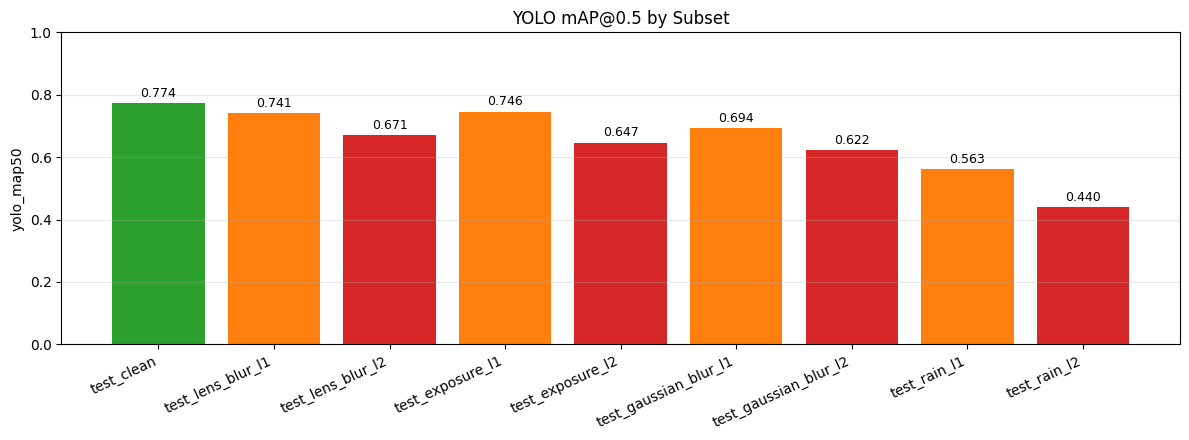

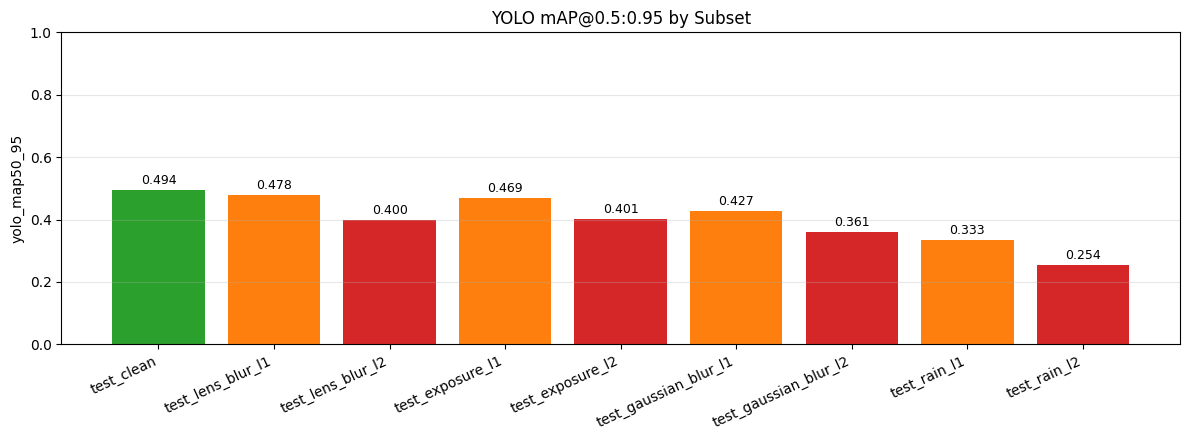

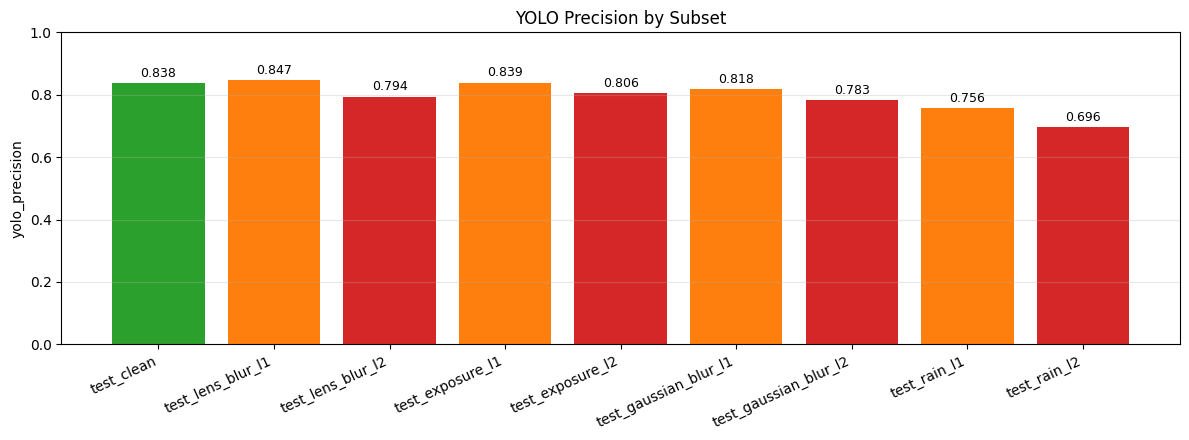

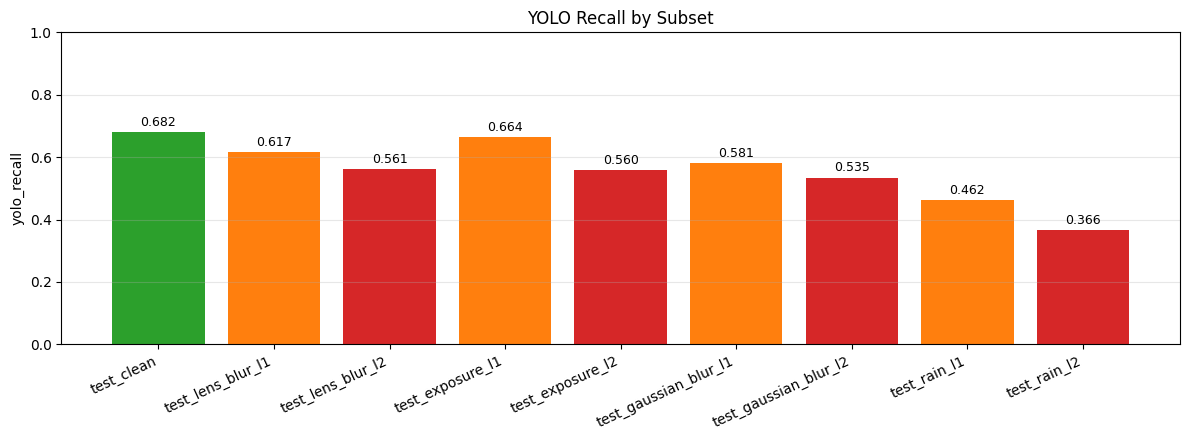

In [34]:
df = df_detector_only.copy()

order = SUBSETS if "SUBSETS" in globals() else list(df["subset"])
df["subset"] = pd.Categorical(df["subset"], categories=order, ordered=True)
df = df.sort_values("subset").reset_index(drop=True)

plot_bar(df, "yolo_map50",     title="YOLO mAP@0.5 by Subset")
plot_bar(df, "yolo_map50_95",  title="YOLO mAP@0.5:0.95 by Subset")
plot_bar(df, "yolo_precision", title="YOLO Precision by Subset")
plot_bar(df, "yolo_recall",    title="YOLO Recall by Subset")


### Performance Degradation of YOLO Detector Relative to Clean Conditions

This computes percentage drop compared to `test_clean`. It is a nice way to quantify robustness degradation.

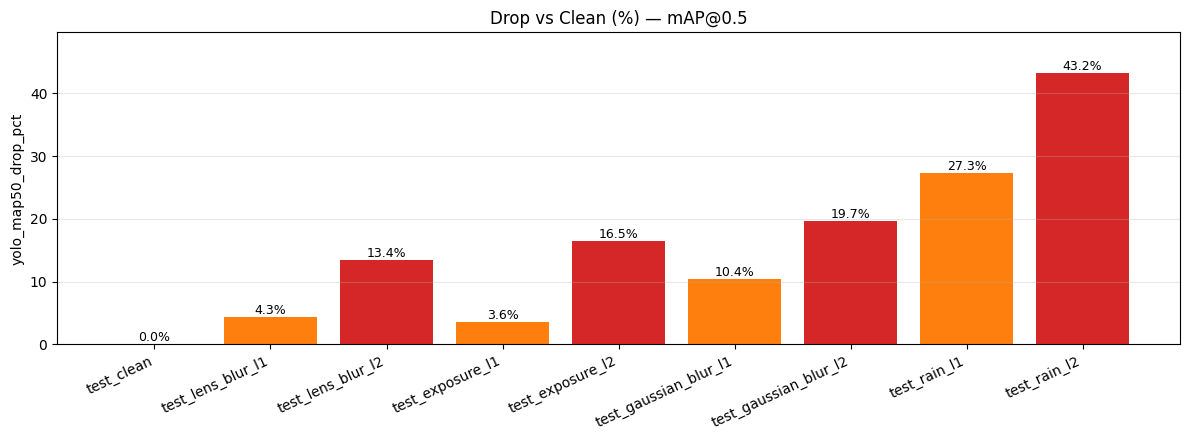

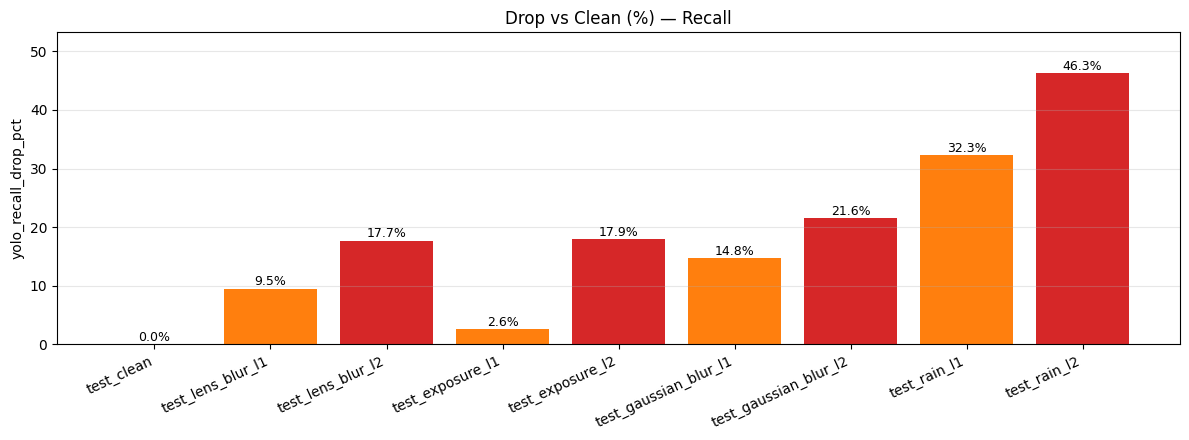

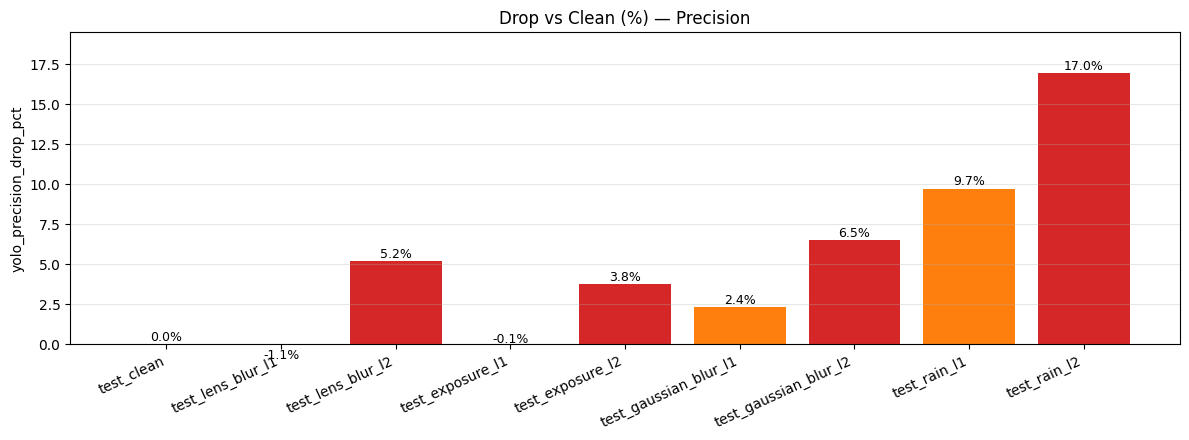

In [36]:
base = df.loc[df["subset"] == "test_clean"].iloc[0]

for metric in ["yolo_map50", "yolo_map50_95", "yolo_precision", "yolo_recall"]:
    df[f"{metric}_drop_pct"] = (base[metric] - df[metric]) / (base[metric] + 1e-9) * 100.0

plot_bar(df, "yolo_map50_drop_pct",    title="Drop vs Clean (%) — mAP@0.5",    ylim=(0, max(5, df["yolo_map50_drop_pct"].max()*1.15)), value_fmt="{:.1f}%")
plot_bar(df, "yolo_recall_drop_pct",   title="Drop vs Clean (%) — Recall",     ylim=(0, max(5, df["yolo_recall_drop_pct"].max()*1.15)), value_fmt="{:.1f}%")
plot_bar(df,"yolo_precision_drop_pct",title="Drop vs Clean (%) — Precision",ylim=(0, max(5, df["yolo_precision_drop_pct"].max() * 1.15)),value_fmt="{:.1f}%")

The quantitative results in above figures present the performance of the YOLO-based detector across clean and progressively degraded test subsets, evaluated using mAP@50, mAP@50–95, precision, and recall metrics.

On the clean test set, the model achieves a mAP@50 of **0.77** and mAP@50–95 of **0.49**, indicating strong baseline detection capability. The relatively high precision (**0.84)** suggests that most predicted bounding boxes are correct, while the recall **(0.68)** shows that a reasonable proportion of ground-truth objects are successfully detected. This confirms that the model performs reliably under nominal visual conditions.

As image degradation severity increases, a consistent decline is observed across all metrics. For both lens blur and exposure distortion, performance degradation is gradual from level 1 to level 2. Notably, recall decreases more sharply than precision, indicating that the model becomes increasingly conservative under visual corruption—fewer objects are detected, but those that are detected tend to be correct. This behavior suggests that degraded visual cues primarily affect object localization and confidence rather than inducing excessive false positives.

The impact is more pronounced for Gaussian blur and especially rain corruption. Under Gaussian blur level 2, mAP@50 drops to **0.62**, and recall falls to **0.53**, reflecting reduced sensitivity to fine-grained features such as edges and contours. Rain conditions present the most severe degradation: at level 2, mAP@50 falls to **0.44** and recall to **0.37**, highlighting the model’s vulnerability to structured noise and occlusions that disrupt object boundaries and texture consistency.

Across all degraded subsets, precision remains consistently higher than recall, even under severe conditions. This indicates that the detector prioritizes prediction confidence, avoiding false positives at the cost of missing objects. While this behavior may be desirable in safety-critical applications where false alarms are costly, it also suggests limited robustness to adverse environmental conditions.

Overall, these results demonstrate that while the YOLO model generalizes reasonably well to mild visual distortions, its performance degrades significantly under severe blur and weather-related artifacts. This highlights the need for robustness-oriented improvements, such as corruption-aware data augmentation, domain-adaptive image restoration to enhance detection reliability in challenging real-world environments. We are focused ,mage restoration we could not make an adaptive resotration stage but fine-tuned and transfer learning made to a Restormer model to this domain.

### CNN-only (Oracle GT crops) per subset

This evaluates the CNN under an `“oracle”` assumption: detection is perfect because crops come from ground-truth boxes. This isolates classification robustness under image corruptions.

For each test image, GT boxes are read, crops are extracted (with a padding), and the CNN predicts classes. The output is `accuracy + macro-F1` per subset, plus an optional confusion matrix stored per subset.

In [37]:
YOLO_IMAGES_ROOT

PosixPath('/Users/emirhan/Desktop/DeepLearning Course Project/curetsd_yolo_single/images')

In [38]:
GT_LABELS_ROOT

PosixPath('/Users/emirhan/Desktop/DeepLearning Course Project/subset/labels/test')

In [39]:
GT_PAD_PX = 6 

@torch.no_grad()
def cnn_predict_batch(pil_crops):
    if len(pil_crops) == 0:
        return [], []

    batch = torch.cat([pil_to_tensor(im, CNN_IMG_SIZE) for im in pil_crops], dim=0).to(CNN_DEVICE)
    logits = cnn(batch)
    probs = torch.softmax(logits, dim=1)
    confs, preds = torch.max(probs, dim=1)
    return preds.cpu().tolist(), confs.cpu().tolist()

def eval_cnn_only_oracle(subset_name: str):
    img_dir = YOLO_IMAGES_ROOT / subset_name
    img_paths = sorted(img_dir.glob("*.jpg"))

    y_true, y_pred = [], []
    total_gt = 0

    for img_path in img_paths:
        stem = img_path.stem
        gt_path = GT_LABELS_ROOT / f"{stem}.txt"

        # Read GT
        gt_objs = read_gt_corner_labels(gt_path)
        if len(gt_objs) == 0:
            continue

        # Open image
        im = Image.open(img_path).convert("RGB")
        W, H = im.size

        # Prepare GT crops
        crops = []
        gt_classes = []
        for obj in gt_objs:
            x1, y1, x2, y2 = corners_to_xyxy(obj["corners"], W, H, pad_px=GT_PAD_PX)
            if x2 <= x1 or y2 <= y1:
                continue
            crop = im.crop((x1, y1, x2, y2))
            crops.append(crop)
            gt_classes.append(int(obj["cls"]))

        preds, _ = cnn_predict_batch(crops)
        y_true.extend(gt_classes)
        y_pred.extend(preds)
        total_gt += len(gt_classes)

    acc, macro_f1, cm = confusion_metrics(y_true, y_pred, num_classes=CNN_NUM_CLASSES)
    out = {
        "cnn_oracle_acc": acc,
        "cnn_oracle_macro_f1": macro_f1,
        "cnn_oracle_num_gt": int(total_gt)
    }
    return out, cm

cnn_only_rows = []
cnn_confusions = {}  # store CM per subset

for s in SUBSETS:
    m, cm = eval_cnn_only_oracle(s)
    m["subset"] = s
    cnn_only_rows.append(m)
    cnn_confusions[s] = cm
    print(s, m)




test_clean {'cnn_oracle_acc': 0.8290341931613677, 'cnn_oracle_macro_f1': 0.6553650444364635, 'cnn_oracle_num_gt': 3334, 'subset': 'test_clean'}
test_lens_blur_l1 {'cnn_oracle_acc': 0.7639472105578884, 'cnn_oracle_macro_f1': 0.6146657781822988, 'cnn_oracle_num_gt': 3334, 'subset': 'test_lens_blur_l1'}
test_lens_blur_l2 {'cnn_oracle_acc': 0.6556688662267547, 'cnn_oracle_macro_f1': 0.5006469296333655, 'cnn_oracle_num_gt': 3334, 'subset': 'test_lens_blur_l2'}
test_exposure_l1 {'cnn_oracle_acc': 0.6994601079784043, 'cnn_oracle_macro_f1': 0.5405866024024398, 'cnn_oracle_num_gt': 3334, 'subset': 'test_exposure_l1'}
test_exposure_l2 {'cnn_oracle_acc': 0.47270545890821836, 'cnn_oracle_macro_f1': 0.22265808285139121, 'cnn_oracle_num_gt': 3334, 'subset': 'test_exposure_l2'}
test_gaussian_blur_l1 {'cnn_oracle_acc': 0.7129574085182964, 'cnn_oracle_macro_f1': 0.6040216272213936, 'cnn_oracle_num_gt': 3334, 'subset': 'test_gaussian_blur_l1'}
test_gaussian_blur_l2 {'cnn_oracle_acc': 0.6169766046790642,

In [40]:
df_cnn_only = pd.DataFrame(cnn_only_rows)
df_cnn_only

,cnn_oracle_acc,cnn_oracle_macro_f1,cnn_oracle_num_gt,subset
0,0.829034,0.655365,3334,test_clean
1,0.763947,0.614666,3334,test_lens_blur_l1
2,0.655669,0.500647,3334,test_lens_blur_l2
3,0.699460,0.540587,3334,test_exposure_l1
4,0.472705,0.222658,3334,test_exposure_l2
5,0.712957,0.604022,3334,test_gaussian_blur_l1
6,0.616977,0.387749,3334,test_gaussian_blur_l2
7,0.583083,0.260587,3334,test_rain_l1
8,0.472406,0.178341,3334,test_rain_l2


In [41]:
df_cnn = df_cnn_only.copy()

order = SUBSETS if "SUBSETS" in globals() else list(df_cnn["subset"])
df_cnn["subset"] = pd.Categorical(df_cnn["subset"], categories=order, ordered=True)
df_cnn = df_cnn.sort_values("subset").reset_index(drop=True)


In [ ]:
base = df_cnn.loc[df_cnn["subset"] == "test_clean"].iloc[0]

for metric in ["cnn_oracle_acc", "cnn_oracle_macro_f1"]:
    df_cnn[f"{metric}_drop_pct"] = (
        (base[metric] - df_cnn[metric]) / (base[metric] + 1e-9) * 100.0
    )


### CNN Classification Performance Using Oracle Ground-Truth Crops

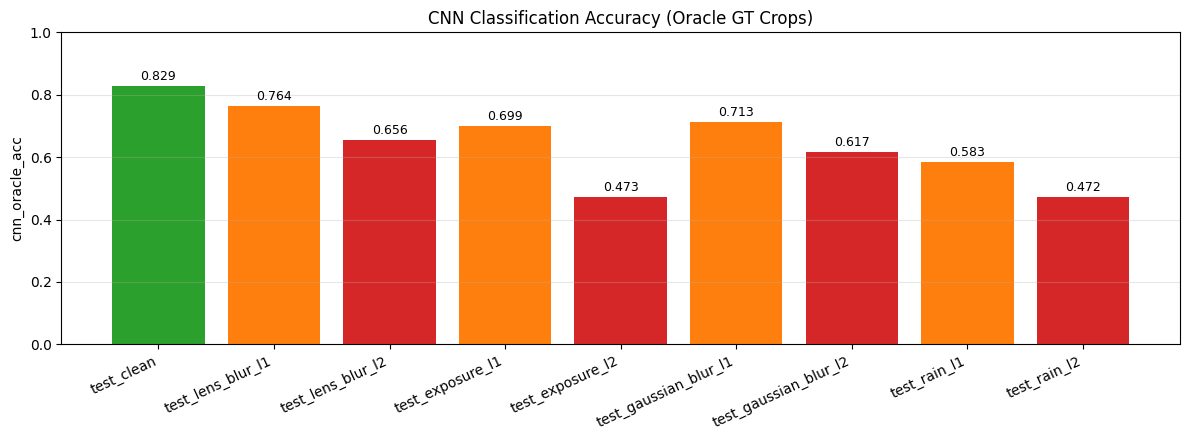

In [42]:
plot_bar(
    df_cnn,
    "cnn_oracle_acc",
    title="CNN Classification Accuracy (Oracle GT Crops)",
    ylim=(0, 1),
    value_fmt="{:.3f}"
)


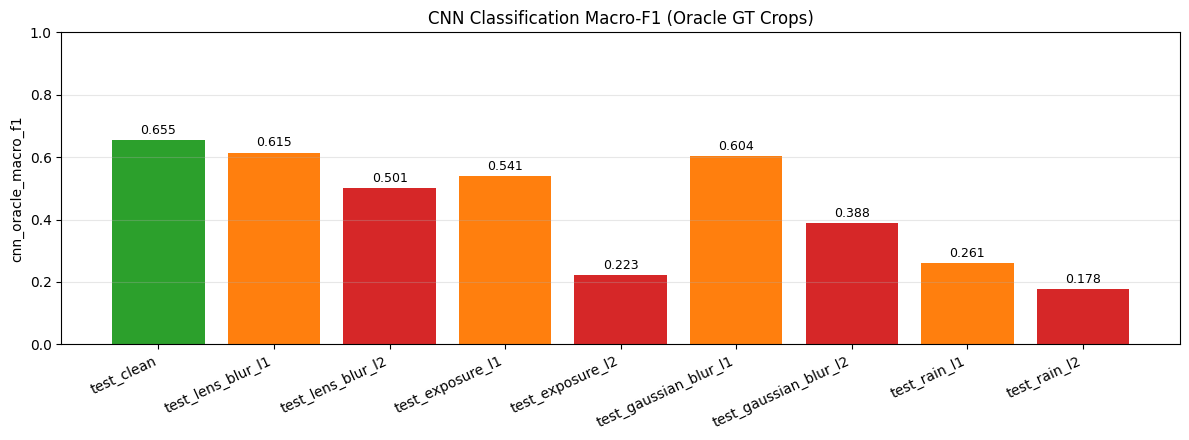

In [43]:
plot_bar(
    df_cnn,
    "cnn_oracle_macro_f1",
    title="CNN Classification Macro-F1 (Oracle GT Crops)",
    ylim=(0, 1),
    value_fmt="{:.3f}"
)


### Performance Degradation of CNN Classifier Relative to Clean Conditions

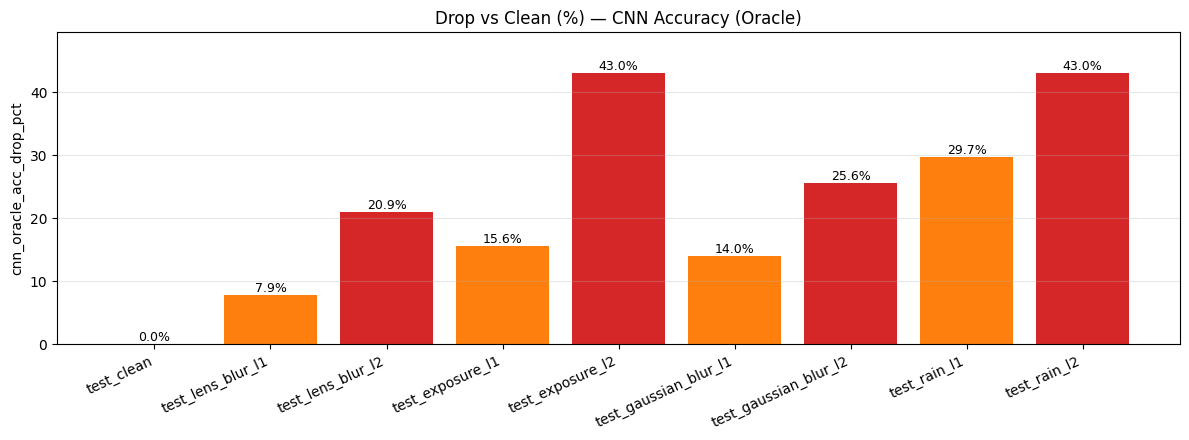

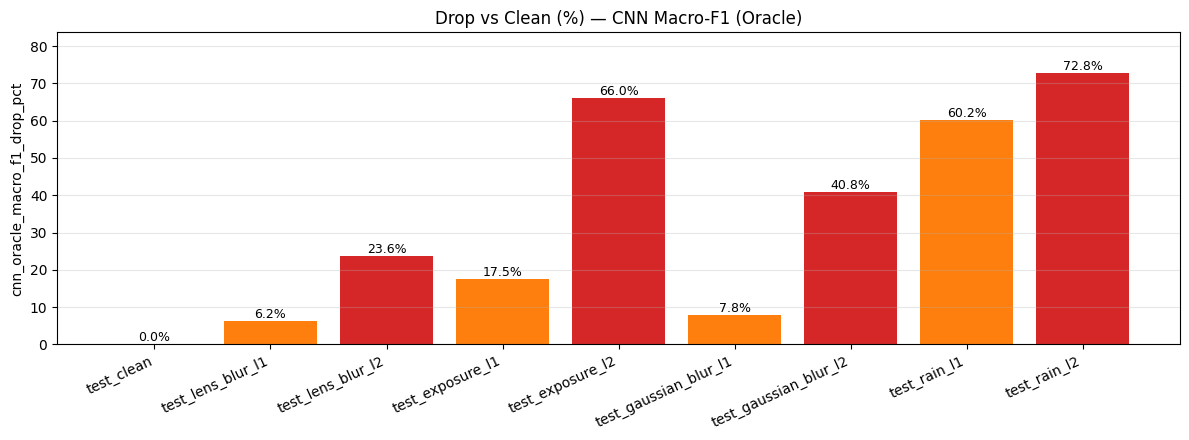

In [46]:
plot_bar(
    df_cnn,
    "cnn_oracle_acc_drop_pct",
    title="Drop vs Clean (%) — CNN Accuracy (Oracle)",
    ylim=(0, max(5, df_cnn["cnn_oracle_acc_drop_pct"].max() * 1.15)),
    value_fmt="{:.1f}%"
)

plot_bar(
    df_cnn,
    "cnn_oracle_macro_f1_drop_pct",
    title="Drop vs Clean (%) — CNN Macro-F1 (Oracle)",
    ylim=(0, max(5, df_cnn["cnn_oracle_macro_f1_drop_pct"].max() * 1.15)),
    value_fmt="{:.1f}%"
)


The CNN-Oracle results represent the upper-bound classification performance assuming perfect localization, where the classifier is evaluated only on ground-truth bounding boxes. As such, these results isolate the classification robustness of the CNN from detection errors and provide insight into how visual degradations affect feature discriminability at the recognition stage.

On the clean test set, the oracle classifier achieves an accuracy of **82.9%** with a macro-averaged F1 score of **0.66**, indicating strong baseline classification performance when high-quality visual cues are available. This confirms that, under ideal localization conditions, the CNN is capable of learning discriminative traffic sign representations.

As visual degradation increases, both accuracy and macro-F1 decrease consistently, with performance drops becoming more pronounced at higher corruption levels. For lens blur and Gaussian blur, level-1 distortions lead to moderate degradation, while level-2 distortions cause substantial performance loss, particularly in macro-F1. This indicates that blur primarily affects class separability, especially for visually similar sign categories.

The impact of exposure distortion and rain is notably more severe. Under exposure level-2, accuracy drops to **47.3%**, while macro-F1 collapses to **0.22**, reflecting significant confusion across classes. Rain conditions show a similar pattern, with macro-F1 falling below **0.18** at level-2. The sharp decline in macro-F1 compared to accuracy suggests increased class imbalance effects and misclassification among minority or visually subtle classes under severe degradations.

Importantly, the number of ground-truth samples remains constant across all subsets, confirming that the observed performance degradation is solely attributable to visual corruption rather than dataset imbalance or sample count variation.

## End-to-End (YOLO → crop → CNN + IoU matching) per subset

This measures realistic pipeline performance:

1) YOLO predicts boxes (single class) with a confidence threshold.  
2) Detections are matched to GT using IoU (greedy matching).  
3) Matched detections are cropped (with small padding) and classified by the CNN.  
4) Metrics combine detection quality and classification correctness.

The key end-to-end score is:

**(number of GT signs that are both detected AND correctly classified) / (total GT signs)**

This makes it easy to compare subset difficulty because it directly measures final task success.

The function also logs per-instance details **(TP/FP/FN, IoU, detection confidence, predicted class, etc.)** which is useful for error analysis later.

The end-to-end (E2E) evaluation measures the joint performance of detection and classification, reflecting the realistic scenario in which a traffic sign must be both detected and correctly classified to be considered a successful prediction. In our evaluation, a detection is counted as correct if it satisfies an IoU threshold of 0.5 and the predicted class label matches the ground truth. The resulting E2E score is defined as:


$ E2E Score= \frac{Numberof_correctly E2E  ground truth signs}{Total number of ground truth signs}$

This metric is intentionally strict and serves as a holistic indicator of system-level robustness.

In [47]:
# End-to-end parameters
E2E_CONF_TH = 0.25
E2E_IOU_TH  = 0.50
DET_PAD_PX  = 4  

@torch.no_grad()
def eval_end2end_subset(subset_name: str):
    img_dir = YOLO_IMAGES_ROOT / subset_name
    img_paths = sorted(img_dir.glob("*.jpg"))

    # Aggregates
    tp = fp = fn = 0
    matched = 0
    correct_class = 0
    total_gt = 0
    total_det_used = 0

    cls_true_matched = []
    cls_pred_matched = []

    detailed_rows = []

    for img_path in img_paths:
        stem = img_path.stem
        gt_path = GT_LABELS_ROOT / f"{stem}.txt"

        # ---- Load GT ----
        im = Image.open(img_path).convert("RGB")
        W, H = im.size

        gt_objs_raw = read_gt_corner_labels(gt_path)
        gts = []
        for obj in gt_objs_raw:
            x1, y1, x2, y2 = corners_to_xyxy(obj["corners"], W, H, pad_px=0)
            if x2 <= x1 or y2 <= y1:
                continue
            gts.append({"xyxy": (x1, y1, x2, y2), "cls": int(obj["cls"])})

        total_gt += len(gts)

        # ---- YOLO Predict ----
        res = yolo.predict(
            source=str(img_path),
            imgsz=YOLO_IMGSZ,
            conf=E2E_CONF_TH,
            iou=0.6,
            device=YOLO_DEVICE,
            verbose=False
        )[0]

        dets = []
        if res.boxes is not None and len(res.boxes) > 0:
            xyxy = res.boxes.xyxy.cpu().numpy()
            confs = res.boxes.conf.cpu().numpy()
            for i in range(len(xyxy)):
                x1, y1, x2, y2 = xyxy[i].tolist()
                x1 = int(clamp(round(x1), 0, W - 1))
                y1 = int(clamp(round(y1), 0, H - 1))
                x2 = int(clamp(round(x2), 0, W - 1))
                y2 = int(clamp(round(y2), 0, H - 1))
                if x2 <= x1 or y2 <= y1:
                    continue
                dets.append({"xyxy": (x1, y1, x2, y2), "conf": float(confs[i])})

        total_det_used += len(dets)

        # ---- IoU Matching ----
        matches, un_det, un_gt = greedy_match(dets, gts, iou_th=E2E_IOU_TH)

        tp += len(matches)
        fp += len(un_det)
        fn += len(un_gt)

        # ---- For matched detections: crop by DET bbox and classify with CNN ----
        match_crops = []
        match_gt_cls = []
        match_meta = []  

        for (di, gi, iou) in matches:
            dx1, dy1, dx2, dy2 = dets[di]["xyxy"]
            gx1, gy1, gx2, gy2 = gts[gi]["xyxy"]
            gt_cls = gts[gi]["cls"]

            # Padding around DET bbox for better CNN crop
            px1 = int(clamp(dx1 - DET_PAD_PX, 0, W - 1))
            py1 = int(clamp(dy1 - DET_PAD_PX, 0, H - 1))
            px2 = int(clamp(dx2 + DET_PAD_PX, 0, W - 1))
            py2 = int(clamp(dy2 + DET_PAD_PX, 0, H - 1))

            crop = im.crop((px1, py1, px2, py2))
            match_crops.append(crop)
            match_gt_cls.append(gt_cls)
            match_meta.append({
                "subset": subset_name,
                "image_name": img_path.name,
                "det_conf": dets[di]["conf"],
                "det_x1": dx1, "det_y1": dy1, "det_x2": dx2, "det_y2": dy2,
                "gt_x1": gx1, "gt_y1": gy1, "gt_x2": gx2, "gt_y2": gy2,
                "gt_cls": gt_cls,
                "iou": float(iou),
            })

        preds, pred_confs = cnn_predict_batch(match_crops)

        for k in range(len(preds)):
            gt_cls = match_gt_cls[k]
            pr = int(preds[k])
            pc = float(pred_confs[k])

            cls_true_matched.append(gt_cls)
            cls_pred_matched.append(pr)

            ok = (pr == gt_cls)
            correct_class += int(ok)
            matched += 1

            row = match_meta[k].copy()
            row["cnn_pred_cls"] = pr
            row["cnn_pred_conf"] = pc
            row["class_correct"] = int(ok)
            row["status"] = "TP"
            detailed_rows.append(row)

        # ---- Log unmatched detections (FP) ----
        for di in un_det:
            dx1, dy1, dx2, dy2 = dets[di]["xyxy"]
            detailed_rows.append({
                "subset": subset_name,
                "image_name": img_path.name,
                "det_conf": dets[di]["conf"],
                "det_x1": dx1, "det_y1": dy1, "det_x2": dx2, "det_y2": dy2,
                "gt_x1": None, "gt_y1": None, "gt_x2": None, "gt_y2": None,
                "gt_cls": None,
                "iou": 0.0,
                "cnn_pred_cls": None,
                "cnn_pred_conf": None,
                "class_correct": 0,
                "status": "FP"
            })

        # ---- Log unmatched GT (FN) ----
        for gi in un_gt:
            gx1, gy1, gx2, gy2 = gts[gi]["xyxy"]
            detailed_rows.append({
                "subset": subset_name,
                "image_name": img_path.name,
                "det_conf": None,
                "det_x1": None, "det_y1": None, "det_x2": None, "det_y2": None,
                "gt_x1": gx1, "gt_y1": gy1, "gt_x2": gx2, "gt_y2": gy2,
                "gt_cls": gts[gi]["cls"],
                "iou": 0.0,
                "cnn_pred_cls": None,
                "cnn_pred_conf": None,
                "class_correct": 0,
                "status": "FN"
            })

    # ---- Metrics ----
    det_p, det_r, det_f1 = det_prf(tp, fp, fn)

    cls_acc, cls_macro_f1, _ = confusion_metrics(cls_true_matched, cls_pred_matched, num_classes=CNN_NUM_CLASSES)

    # End-to-end score: (detected AND correctly classified) / (total GT signs)
    e2e_score = (correct_class / (total_gt + 1e-9)) if total_gt > 0 else 0.0

    out = {
        "e2e_det_precision": det_p,
        "e2e_det_recall": det_r,
        "e2e_det_f1": det_f1,
        "e2e_cls_acc_matched": cls_acc,
        "e2e_cls_macro_f1_matched": cls_macro_f1,
        "e2e_score": float(e2e_score),
        "num_images": int(len(img_paths)),
        "num_gt": int(total_gt),
        "num_dets": int(total_det_used),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "matched": int(matched),
        "correct_class": int(correct_class),
    }
    return out, detailed_rows

e2e_rows = []
all_details = []

for s in SUBSETS:
    m, details = eval_end2end_subset(s)
    m["subset"] = s
    e2e_rows.append(m)
    all_details.extend(details)
    print(s, m)

df_e2e = pd.DataFrame(e2e_rows)
df_details = pd.DataFrame(all_details)



test_clean {'e2e_det_precision': 0.871242891957404, 'e2e_det_recall': 0.64337132573466, 'e2e_det_f1': 0.7401656309810413, 'e2e_cls_acc_matched': 0.882051282051282, 'e2e_cls_macro_f1_matched': 0.7088205640698094, 'e2e_score': 0.5674865026992899, 'num_images': 2102, 'num_gt': 3334, 'num_dets': 2462, 'tp': 2145, 'fp': 317, 'fn': 1189, 'matched': 2145, 'correct_class': 1892, 'subset': 'test_clean'}
test_lens_blur_l1 {'e2e_det_precision': 0.8906752411571471, 'e2e_det_recall': 0.5815836832631729, 'e2e_det_f1': 0.7036835415286781, 'e2e_cls_acc_matched': 0.8468282619907168, 'e2e_cls_macro_f1_matched': 0.7625339250640165, 'e2e_score': 0.49250149969991225, 'num_images': 2102, 'num_gt': 3334, 'num_dets': 2177, 'tp': 1939, 'fp': 238, 'fn': 1395, 'matched': 1939, 'correct_class': 1642, 'subset': 'test_lens_blur_l1'}
test_lens_blur_l2 {'e2e_det_precision': 0.8460048426146024, 'e2e_det_recall': 0.5239952009596509, 'e2e_det_f1': 0.6471568804312541, 'e2e_cls_acc_matched': 0.7876359473382942, 'e2e_cls_m

In [49]:
df_e2e

,e2e_det_precision,e2e_det_recall,e2e_det_f1,e2e_cls_acc_matched,e2e_cls_macro_f1_matched,e2e_score,num_images,num_gt,num_dets,tp,fp,fn,matched,correct_class,subset
0,0.871243,0.643371,0.740166,0.882051,0.708821,0.567487,2102,3334,2462,2145,317,1189,2145,1892,test_clean
1,0.890675,0.581584,0.703684,0.846828,0.762534,0.492501,2102,3334,2177,1939,238,1395,1939,1642,test_lens_blur_l1
2,0.846005,0.523995,0.647157,0.787636,0.655741,0.412717,2102,3334,2065,1747,318,1587,1747,1376,test_lens_blur_l2
3,0.869077,0.627175,0.728571,0.775705,0.628827,0.486503,2102,3334,2406,2091,315,1243,2091,1622,test_exposure_l1
4,0.842080,0.524595,0.646461,0.599200,0.347133,0.314337,2102,3334,2077,1749,328,1585,1749,1048,test_exposure_l2
5,0.869014,0.555189,0.677526,0.800108,0.731869,0.444211,2102,3334,2130,1851,279,1483,1851,1481,test_gaussian_blur_l1
6,0.805147,0.525495,0.635935,0.747146,0.520020,0.392621,2102,3334,2176,1752,424,1582,1752,1309,test_gaussian_blur_l2
7,0.824623,0.425915,0.561709,0.819014,0.388565,0.348830,2102,3334,1722,1420,302,1914,1420,1163,test_rain_l1
8,0.790230,0.329934,0.465510,0.776364,0.324585,0.256149,2102,3334,1392,1100,292,2234,1100,854,test_rain_l2


### Performance under Clean Conditions

On the clean test set, the system achieves an E2E score of 0.57, with high detection precision (0.87) and moderate detection recall (0.64). The classification accuracy on matched detections reaches 88.2%, indicating that once signs are detected, the CNN classifier performs reliably.

Despite strong individual component performance, the E2E score is noticeably lower than both standalone detection and oracle classification results. This highlights an important characteristic of end-to-end systems: errors compound across stages, and moderate recall loss at the detection stage directly limits final task success.

### Effect of Increasing Visual Degradation

As challenge severity increases, a consistent and monotonic degradation is observed across all E2E metrics.

Lens blur and Gaussian blur cause gradual degradation, primarily driven by decreasing detection recall and reduced classification accuracy on matched detections.

Exposure distortion introduces a more severe drop at level 2, where classification macro-F1 collapses to **0.35**, indicating strong inter-class confusion even when detections are correct.

Rain corruption produces the most severe degradation. At level 2, detection recall falls below **0.33**, and the E2E score drops to **0.26**, meaning that fewer than one-third of traffic signs are successfully detected and classified.

Across all challenging subsets, precision remains consistently higher than recall, indicating conservative detection behavior. While this reduces false positives, it significantly penalizes the E2E score due to missed detections.

### Merge Summary Tables & Save

This merges detector-only, CNN-only, and end-to-end metrics into one table and saves both:
- a summary CSV (one row per subset)
- a detailed CSV (per detection/GT instance for debugging)

In [50]:
df_summary = df_detector_only.merge(df_cnn_only, on="subset", how="outer").merge(df_e2e, on="subset", how="outer")

In [51]:
summary_csv = OUT_DIR / "results_raw_summary.csv"
details_csv = OUT_DIR / "results_raw_details.csv"

df_summary.to_csv(summary_csv, index=False)
df_details.to_csv(details_csv, index=False)

print("Saved summary:", summary_csv)
print("Saved details:", details_csv)

Saved summary: /Users/emirhan/Desktop/DeepLearning Course Project/eval_raw_curetsd/results_raw_summary.csv
Saved details: /Users/emirhan/Desktop/DeepLearning Course Project/eval_raw_curetsd/results_raw_details.csv


### Plots (subset comparison)

The final plots show trends across subsets for:
- Detector-only mAP50  
- CNN oracle accuracy  
- End-to-end score 

In [ ]:
order = SUBSETS
dfp = df_summary.set_index("subset").loc[order].reset_index()

x = np.arange(len(order))
labels = order

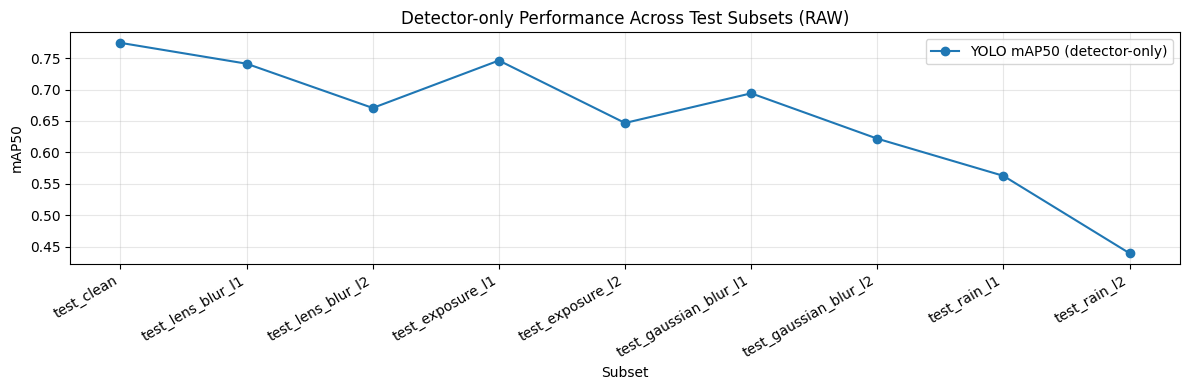

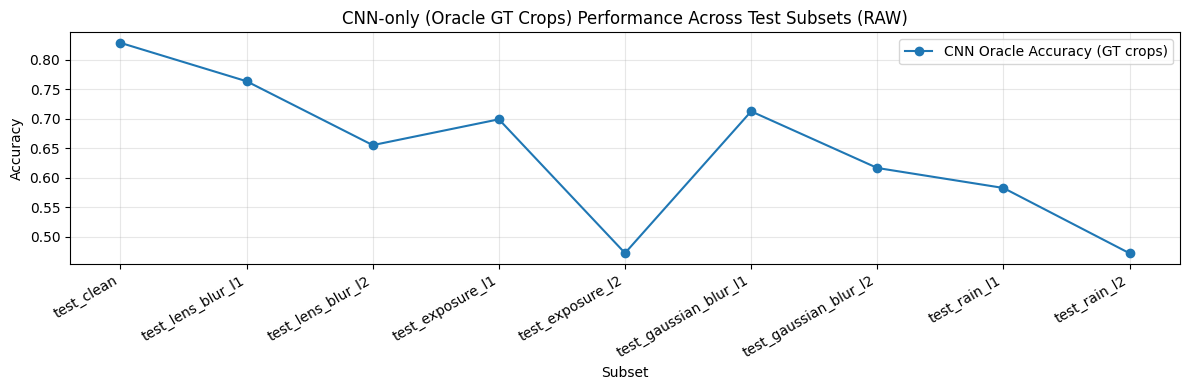

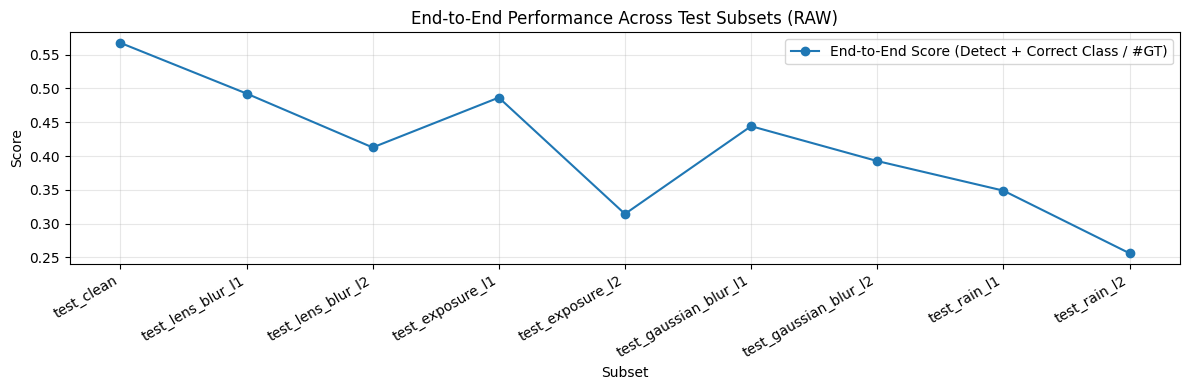

In [52]:
# --- Plot 1: Detector-only mAP50 ---
plt.figure(figsize=(12, 4))
plt.plot(x, dfp["yolo_map50"].values, marker="o", label="YOLO mAP50 (detector-only)")
plt.xticks(x, labels, rotation=30, ha="right")
plt.title("Detector-only Performance Across Test Subsets (RAW)")
plt.xlabel("Subset")
plt.ylabel("mAP50")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: CNN-only Oracle Accuracy ---
plt.figure(figsize=(12, 4))
plt.plot(x, dfp["cnn_oracle_acc"].values, marker="o", label="CNN Oracle Accuracy (GT crops)")
plt.xticks(x, labels, rotation=30, ha="right")
plt.title("CNN-only (Oracle GT Crops) Performance Across Test Subsets (RAW)")
plt.xlabel("Subset")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: End-to-End Score ---
plt.figure(figsize=(12, 4))
plt.plot(x, dfp["e2e_score"].values, marker="o", label="End-to-End Score (Detect + Correct Class / #GT)")
plt.xticks(x, labels, rotation=30, ha="right")
plt.title("End-to-End Performance Across Test Subsets (RAW)")
plt.xlabel("Subset")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Cross-Analysis of Detection, Oracle Classification, and End-to-End Performance

This notebook evaluates traffic sign recognition under challenging conditions through three complementary perspectives: YOLO-based detection, CNN-Oracle classification, and end-to-end (E2E) detection–classification performance. Together, these analyses reveal how performance degrades across system components and how errors compound in realistic deployment settings based on CURE-TSD subset created by us.

### Baseline Capability under Clean Conditions

- Under clean conditions, all three evaluation modes demonstrate strong baseline performance.
YOLO achieves high detection precision and solid recall, the CNN-Oracle classifier reaches over **82%** accuracy and **0.66** macro-F1, and the E2E system correctly detects and classifies approximately **57%** of all ground-truth signs.

- Despite strong component-level performance, the E2E score is substantially lower than either standalone detection or oracle classification results. This immediately highlights a fundamental system-level property: end-to-end performance is bounded by the weakest stage, and even moderate detection recall loss directly limits final task success.

### Detection as the First Bottleneck: YOLO Results

- Across all challenging subsets, YOLO detection exhibits a consistent precision–recall imbalance. Precision remains relatively stable—even under severe corruption—while recall degrades sharply as challenge severity increases.

- This behavior indicates that the detector becomes increasingly conservative, prioritizing confidence over coverage. As a result, many traffic signs are missed entirely, particularly under rain, blur, and severe exposure distortion. Since missed detections cannot be recovered by downstream stages, detection recall emerges as the primary bottleneck in the E2E pipeline.

### Classification Robustness Limits: CNN-Oracle Results

- The CNN-Oracle analysis isolates classification performance by assuming perfect localization. While classification accuracy and macro-F1 are strong under clean conditions, they degrade significantly under severe distortions.

- Exposure level 2 and rain cause macro-F1 to collapse below **0.25**, despite a constant number of ground-truth samples.

- The gap between accuracy and macro-F1 widens under severe corruption, indicating increased inter-class confusion and sensitivity to visually subtle features.

- These results demonstrate that even perfect detection cannot guarantee reliable recognition under adverse conditions. Classification robustness therefore constitutes a second, independent bottleneck, particularly at higher challenge levels.

### Error Compounding in End-to-End Evaluation

- The E2E results integrate both failure modes and exhibit the largest performance degradation across all settings. While detection precision remains high, the combined effects of recall loss and classification errors significantly reduce the final E2E score.

- Under severe conditions such as rain level 2, fewer than one-third of ground-truth signs are successfully detected and correctly classified. Importantly, E2E degradation is not linear: modest losses at each stage compound multiplicatively, leading to a disproportionately large drop in system-level performance.

- This confirms that E2E evaluation provides a more realistic and stricter assessment of deployment readiness than detection or classification metrics alone.

### Consistency with Benchmark Trends

- The observed degradation patterns closely mirror those reported in the original Traffic Sign Detection under Challenging Conditions benchmark:

- Recall degrades more severely than precision.

- Weather-related and illumination-based distortions cause the largest performance drops.

Thus, despite architectural and metric differences, the raw results demonstrate strong consistency with established benchmark behavior.